Preparación y Escalamiento

In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Cargar el dataset (usamos el crudo y lo preprocesamos rápido para exploración completa)
BASE_DIR = Path(os.getcwd()).parent
raw_path = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(raw_path)

# Limpieza rápida (igual que en tu script)
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df = df.drop(columns=['customerID'])

# Separar la variable objetivo solo para colorear gráficos después
y_real = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

# Convertir variables categóricas en numéricas (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# Escalamiento (Requisito fundamental para Clustering y PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print(f"Datos escalados listos para exploración No Supervisada. Forma: {X_scaled.shape}")

Datos escalados listos para exploración No Supervisada. Forma: (7043, 30)


PCA (Análisis de Componentes Principales)

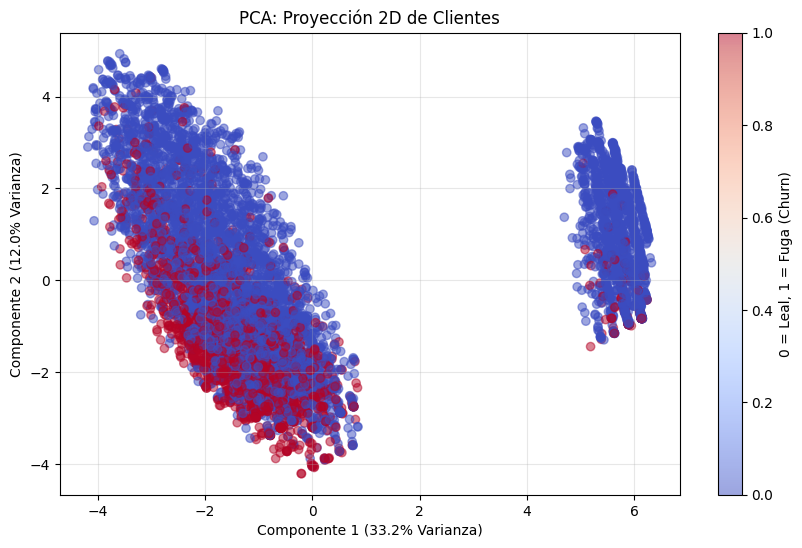

In [2]:
# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
# Coloreamos según la fuga real para ver si PCA logra separarlos naturalmente
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_real, cmap='coolwarm', alpha=0.5)

plt.title('PCA: Proyección 2D de Clientes')
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]:.1%} Varianza)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]:.1%} Varianza)')
plt.colorbar(scatter, label='0 = Leal, 1 = Fuga (Churn)')
plt.grid(True, alpha=0.3)
plt.show()

Clustering Jerárquico (Dendrograma)

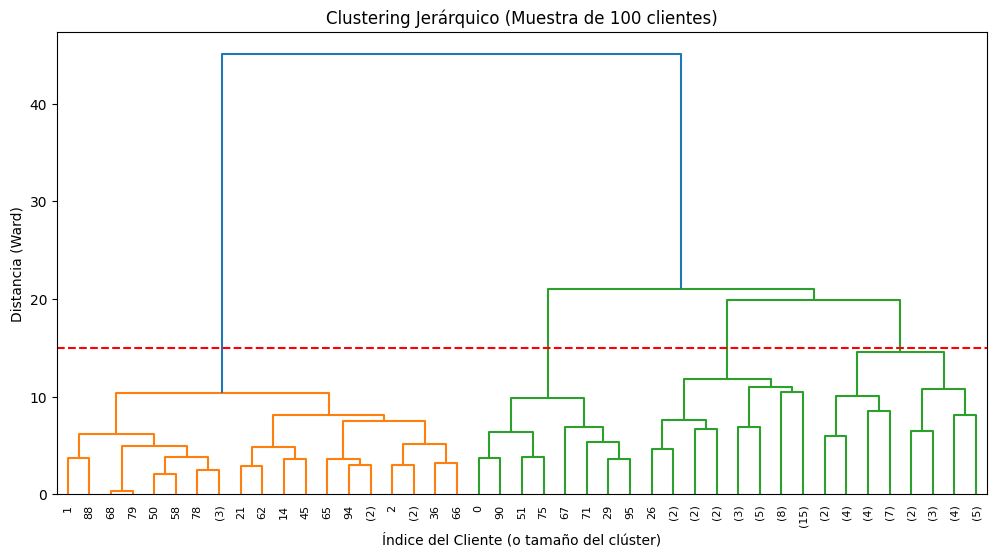

In [3]:
# Tomamos una muestra aleatoria de 100 clientes para el dendrograma
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], 100, replace=False)
X_sample = X_scaled[sample_indices]

# Calcular las distancias jerárquicas
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Clustering Jerárquico (Muestra de 100 clientes)')
plt.xlabel('Índice del Cliente (o tamaño del clúster)')
plt.ylabel('Distancia (Ward)')
plt.axhline(y=15, color='r', linestyle='--') # Línea de corte teórica
plt.show()

K-Means Clustering

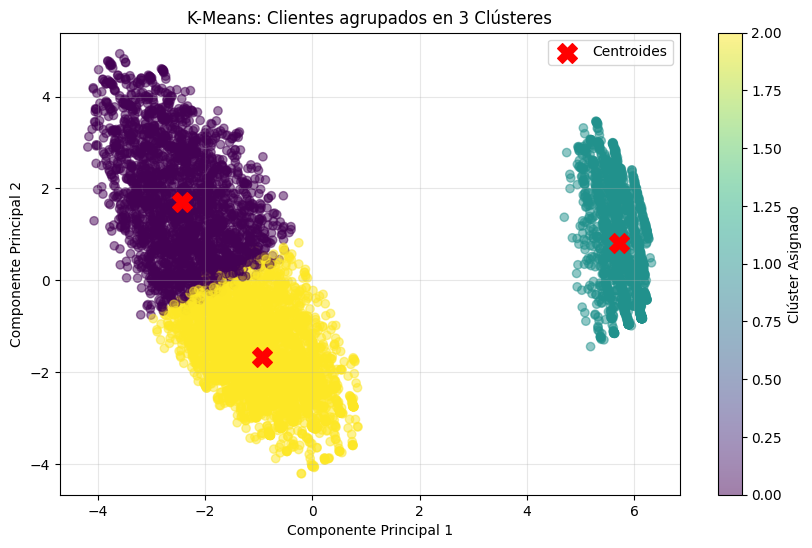

In [4]:
# Aplicar K-Means para 3 clústeres
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Graficamos los clústeres sobre nuestra proyección PCA anterior
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)

# Marcar los centroides
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.title('K-Means: Clientes agrupados en 3 Clústeres')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Clúster Asignado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()